# Location Prediction of Birds by Country





In [1]:
import glob
import os
import polars as pl
import pandas as pd
import numpy as np
import folium
import geopandas as gpd
# from birds.settings import load_settings
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from sklearn.utils.multiclass import unique_labels
from sklearn.model_selection import StratifiedShuffleSplit

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def load_agg_data_files(nfiles):
    data_dir = '/content/drive/MyDrive/M2-data/notebooks/data/augmented_data/band_agg/'
    print(data_dir)

    all_files = sorted(glob.glob(os.path.join(data_dir, "nabbp_band_agg_*.parquet")))

    if nfiles > 0:
        all_files = all_files[-nfiles:]

    print(f"Loading {len(all_files)} files from {data_dir}")
    df = pl.concat([pl.read_parquet(f) for f in all_files])
    return df


df = load_agg_data_files(99)

/content/drive/MyDrive/M2-data/notebooks/data/augmented_data/band_agg/
Loading 57 files from /content/drive/MyDrive/M2-data/notebooks/data/augmented_data/band_agg/


In [4]:
df.estimated_size()

814573180

In [25]:
df.head(5)

banding_record_id,banding_band,banding_date,banding_day,banding_month,banding_year,banding_species_id,banding_iso_country,banding_iso_subdivision,banding_band_type_code,banding_bird_status,banding_age_code,banding_sex_code,banding_event_type,banding_band_status_code,banding_extra_info_code,banding_lat_dd,banding_lon_dd,banding_coordinates_precision_code,banding_permit,banding_record_source,num_events,last_event_date,last_how_obtained_code,last_who_obtained_code,last_reporting_method,last_present_condition,last_lat_dd,last_lon_dd,last_iso_country,last_iso_subdivision,event_days_span,first_to_last_km
i64,str,date,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,i64,date,i64,i64,i64,i64,f64,f64,str,str,i64,f64
-42574156,"""B58235077397""",2005-07-29,29,7,2005,1691,"""CA""","""CA-ON""","""1""","""3""","""1""","""5""","""B""","""0""","""00""",55.5,-83.5,"""60.0""","""P8832232""","""B""",1,2005-10-13,1,21,6,3,52.41667,-109.25,"""CA""","""CA-SK""",76,1708.745971
-16205515,"""B17815174927""",2017-07-15,15,7,2017,1710,"""CA""","""CA-NU""","""41""","""3""","""1""","""5""","""B""","""0""","""00""",67.5,-101.5,"""60.0""","""P7837928""","""B""",1,2018-12-08,1,21,7,5,34.30495,-91.98342,"""US""","""US-AR""",511,3741.442839
19818780,"""B67765371626""",2023-07-19,19,7,2023,1690,"""CA""","""CA-NT""","""9999""","""3""","""5""","""5""","""B""","""0""","""00""",72.5,-124.5,"""60.0""","""P8830613""","""B""",1,2025-04-09,1,21,7,5,50.57183,-112.95173,"""CA""","""CA-AB""",630,2503.432432
-42853666,"""B88845010098""",1976-10-29,29,10,1976,1690,"""US""","""US-NE""","""11""","""3""","""1""","""5""","""B""","""0""","""19""",41.5,-96.5,"""60.0""","""P9953434""","""B""",1,1981-12-06,1,20,1,5,40.75,-95.58333,"""US""","""US-IA""",1864,113.357308
-42949648,"""B48495419884""",2003-08-02,2,8,2003,1690,"""US""","""US-AK""","""1""","""3""","""4""","""4""","""B""","""0""","""00""",70.5,-154.5,"""60.0""","""P4741797""","""B""",1,2009-05-22,1,21,61,5,69.41667,-130.25,"""CA""","""CA-NT""",2120,925.553743


In [26]:
df.columns

['banding_record_id',
 'banding_band',
 'banding_date',
 'banding_day',
 'banding_month',
 'banding_year',
 'banding_species_id',
 'banding_iso_country',
 'banding_iso_subdivision',
 'banding_band_type_code',
 'banding_bird_status',
 'banding_age_code',
 'banding_sex_code',
 'banding_event_type',
 'banding_band_status_code',
 'banding_extra_info_code',
 'banding_lat_dd',
 'banding_lon_dd',
 'banding_coordinates_precision_code',
 'banding_permit',
 'banding_record_source',
 'num_events',
 'last_event_date',
 'last_how_obtained_code',
 'last_who_obtained_code',
 'last_reporting_method',
 'last_present_condition',
 'last_lat_dd',
 'last_lon_dd',
 'last_iso_country',
 'last_iso_subdivision',
 'event_days_span',
 'first_to_last_km']

In [5]:
cols = [
    'banding_record_source',
    'banding_month',
    'last_present_condition',
    'banding_age_code',
    'banding_sex_code',
    'banding_band_type_code',
    'banding_species_id',
    'last_reporting_method',
    'banding_extra_info_code',
    'last_how_obtained_code',
    'banding_lat_dd',
    'banding_lon_dd',
    'banding_iso_subdivision'
]

df = df[cols]

In [6]:
na_lat_bounds = (7, 84)
na_lon_bounds = (-168, -52)

# drop_nulls
df = df.drop_nulls(subset=['banding_lat_dd', 'banding_lon_dd'])

# only points within north america
df = df.filter(
    (pl.col('banding_lat_dd') >= na_lat_bounds[0]) & (pl.col('banding_lat_dd') <= na_lat_bounds[1]) &
    (pl.col('banding_lon_dd') >= na_lon_bounds[0]) & (pl.col('banding_lon_dd') <= na_lon_bounds[1])
)

# Filter out rows where both lat and lon are zero, null island
df = df.filter(~((pl.col('banding_lat_dd') == 0) & (pl.col('banding_lon_dd') == 0)))

df.select(['banding_lat_dd', 'banding_lon_dd']).describe()

statistic,banding_lat_dd,banding_lon_dd
str,f64,f64
"""count""",4.26672e6,4.26672e6
"""null_count""",0.0,0.0
"""mean""",44.171408,-94.011801
"""std""",8.385297,18.923805
"""min""",7.91667,-167.5
"""25%""",39.5,-104.27083
"""50%""",42.5,-90.5
"""75%""",47.5,-80.41667
"""max""",82.58333,-52.5


In [7]:
# Add 'season' column based on 'event_month' (1=Jan, 12=Dec)
df = df.with_columns(
    pl.col('banding_month').cast(pl.Int64).alias('banding_month')
)
df = df.filter(pl.col('banding_month').is_not_null())

df = df.with_columns(
    pl.when(pl.col('banding_month').is_in([12, 1, 2])).then(pl.lit('winter'))
    .when(pl.col('banding_month').is_in([3, 4, 5])).then(pl.lit('spring'))
    .when(pl.col('banding_month').is_in([6, 7, 8])).then(pl.lit('summer'))
    .when(pl.col('banding_month').is_in([9, 10, 11])).then(pl.lit('fall'))
    .otherwise(pl.lit('unknown'))
    .alias('season')
)

In [30]:
n_points = 5000
sample_df = df.sample(n=n_points)
raw_map = folium.Map(location=[40, -100], zoom_start=3)  # Center of North America

for row in sample_df.iter_rows(named=True):
    if pd.notnull(row['banding_lat_dd']) and pd.notnull(row['banding_lon_dd']):
        folium.CircleMarker(
            location=[row['banding_lat_dd'], row['banding_lon_dd']],
            radius=2,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.5
        ).add_to(raw_map)

# Display the map
raw_map

In [31]:
# Note: tried to use the lookup table but there were too many NULL values
# iso = '/content/drive/MyDrive/M2-data/notebooks/data/lookups/country_state.csv'
# iso_df = pd.read_csv(iso)
# iso_df.head(20)


In [30]:
# Assign country to each row in df based on lat_dd/lon_dd and world geometry

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world.head()

points_gdf = gpd.GeoDataFrame(df.to_pandas(), geometry=gpd.points_from_xy(df['banding_lon_dd'].to_numpy(), df['banding_lat_dd'].to_numpy()), crs=world.crs)
country_name = "ADMIN"
joined = gpd.sjoin(points_gdf, world[['geometry', country_name]], how='left', predicate='within')

# Drop rows where the country name is null (instead of filling with 'Unknown')
joined = joined.dropna(subset=[country_name])

# Handle potential NaN values in the country column before converting to Polars
country_values = joined[country_name].values
df = pl.from_pandas(joined[df.columns].copy())
df = df.with_columns(pl.Series(name='country_from_geom', values=country_values))
df['country_from_geom'].value_counts()

country_from_geom,count
str,u32
"""Cuba""",33
"""The Bahamas""",23
"""Costa Rica""",68
"""Honduras""",30
"""Canada""",988812
…,…
"""Dominican Republic""",19
"""United States of America""",2869392
"""El Salvador""",11


In [ ]:
# --- Feature Selection: Evaluate feature importance for geolocation prediction ---

feature_cols = [
    'banding_record_source',
    'banding_month',
    'last_present_condition',
    'banding_age_code',
    'banding_sex_code',
    'banding_band_type_code',
    'banding_species_id',
    'last_reporting_method',
    'banding_extra_info_code',
    'last_how_obtained_code',
    'season'
]

# Convert Polars DataFrame to pandas for scikit-learn
X_fs = df.select(feature_cols).to_pandas()
y_fs = df.select('country_from_geom').to_pandas()

# Encode all object/categorical columns in the pandas DataFrame
for col in X_fs.select_dtypes(include=['object', 'category']).columns:
    X_fs[col] = LabelEncoder().fit_transform(X_fs[col].astype(str))

# Encode categorical target
le = LabelEncoder()
y_fs = le.fit_transform(y_fs['country_from_geom'].astype(str))

# Fit a random forest for feature importance
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_fs, y_fs)
importances = rf_fs.feature_importances_

# Show feature importances
feature_importance_df = pd.DataFrame({'feature': X_fs.columns, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
print('Feature importances for geolocation prediction (predicting country_from_geom):')
print(feature_importance_df)
plt.figure(figsize=(8,6)) # Increased figure height
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances for Predicting country_from_geom')
plt.gca().invert_yaxis()
plt.show()

In [27]:
# Use the most important features for prediction (from feature selection)
selected_features = ['banding_species_id', 'banding_month', 'season', 'banding_age_code', 'banding_band_type_code', 'banding_extra_info_code']
selected_features = [f for f in selected_features if f in df.columns]

X_pl = df.select(selected_features)
y_pl = df.select('country_from_geom')

# One-hot encode 'season'
if 'season' in X_pl.columns:
    # Polars get_dummies function for one-hot encoding
    X_pl = X_pl.to_dummies(columns=['season'])

# Convert Polars DataFrames to pandas DataFrames for scikit-learn
X = X_pl.to_pandas()
y = y_pl.to_pandas().squeeze()

# Fill missing values for numeric columns in the pandas DataFrame
for col in X.select_dtypes(include=[np.number]).columns:
    X[col] = X[col].fillna(X[col].median())

# Encode remaining categorical columns
for col in X.select_dtypes(include=['object', 'category']).columns:
     X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Encode country column (target var)
le = LabelEncoder()
y = le.fit_transform(y.astype(str))


# To address class imbalance, use stratified sampling and class_weight in the classifier
y_series = pd.Series(y)
mask = ~y_series.isna()
X = X[mask]
y = y_series[mask].values

# Filter for classes with at least 2 samples in the full dataset before sampling
y_series_full_filtered = pd.Series(y)
value_counts_full = y_series_full_filtered.value_counts()
valid_classes_full = value_counts_full[value_counts_full >= 2].index

X = X[y_series_full_filtered.isin(valid_classes_full)].reset_index(drop=True) # Reset index after filtering
y = y_series_full_filtered[y_series_full_filtered.isin(valid_classes_full)].values # Convert back to numpy array


n_samples = df.estimated_size() #OPTIONAL: change to smaller number if you want to run faster for testing

if len(X) > n_samples:
    # Sample indices while preserving the distribution of the target variable
    sss = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=42)
    train_index, _ = next(sss.split(X, y))

    X = X.iloc[train_index].reset_index(drop=True) # Reset index after sampling
    y = y[train_index]

# After sampling, ensure there are no classes with only one sample before splitting
y_series_sampled = pd.Series(y)
value_counts_sampled = y_series_sampled.value_counts()
valid_classes_sampled = value_counts_sampled[value_counts_sampled >= 2].index

# Filter X and y to keep only samples from valid classes in the sampled data
X = X[y_series_sampled.isin(valid_classes_sampled)].reset_index(drop=True) # Reset index after filtering
y = y_series_sampled[y_series_sampled.isin(valid_classes_sampled)].values # Convert back to numpy array

# Stratified split to preserve rare classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Compute class weights to help model learn rare classes
classes = np.unique(y_train)
weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weight_dict)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [28]:
print(len(y_train), len(y_test))

3413375 853344


Accuracy: 0.76


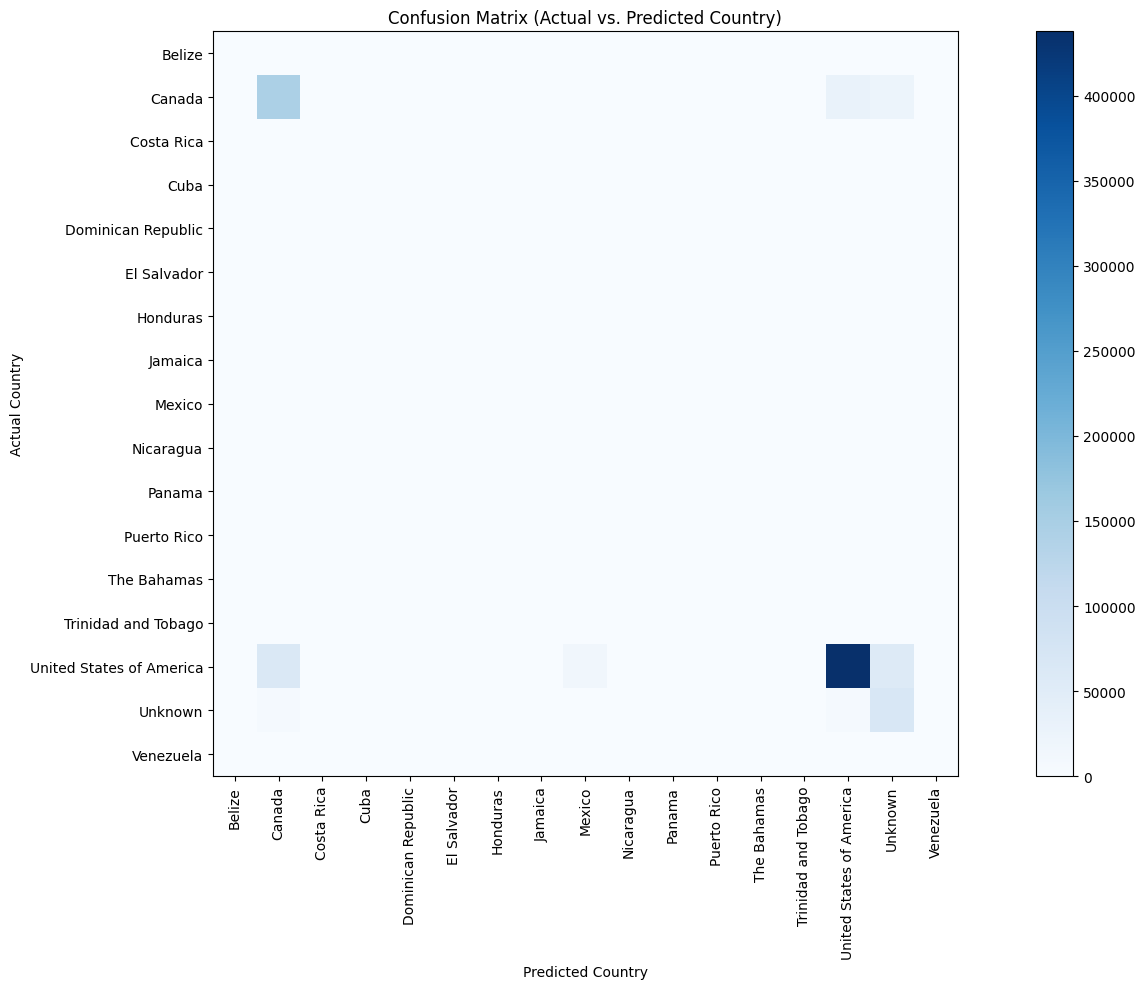

In [29]:
# Evaluate accuracy and show confusion matrix for country prediction

# Ensure y_test and y_pred are not None or empty
if y_test is None or y_pred is None or len(y_test) == 0 or len(y_pred) == 0:
    print("y_test or y_pred is empty. Cannot calculate accuracy or confusion matrix.")
else:
    # The previous step ensures y_test and y_pred are NumPy arrays with no NaNs or classes with < 2 samples
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.2f}")

    # Calculate confusion matrix
    # Get the unique classes that were actually present in the test set and predicted
    labels_encoded = unique_labels(y_test, y_pred)

    # Decode the numeric labels back to country names using the fitted LabelEncoder
    # Ensure 'le' is available from the previous cell's execution
    labels_decoded = le.inverse_transform(labels_encoded)

    cm = confusion_matrix(y_test, y_pred, labels=labels_encoded)

    plt.figure(figsize=(16,10))
    plt.imshow(cm, cmap='Blues')
    plt.title('Confusion Matrix (Actual vs. Predicted Country)')
    plt.xlabel('Predicted Country')
    plt.ylabel('Actual Country')
    # Use the decoded country names for the axis ticks
    plt.xticks(ticks=np.arange(len(labels_decoded)), labels=labels_decoded, rotation=90)
    plt.yticks(ticks=np.arange(len(labels_decoded)), labels=labels_decoded)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [18]:
# Visualize a sample of predictions on a folium map (country prediction)

sample_indices = X_test.sample(n=min(200, len(X_test)), random_state=42).index
sampled_df_subset = df.to_pandas().loc[sample_indices, ['banding_lat_dd', 'banding_lon_dd', 'country_from_geom']]
actual_countries_encoded = y_test[X_test.index.get_indexer(sample_indices)]
predicted_countries_encoded = y_pred[X_test.index.get_indexer(sample_indices)]

# Decode the country labels using the LabelEncoder fitted in the previous cell
actual_countries_decoded = le.inverse_transform(actual_countries_encoded)
predicted_countries_decoded = le.inverse_transform(predicted_countries_encoded)

# Create a new DataFrame for mapping with decoded country names
sample_map_data = sampled_df_subset.copy()
sample_map_data['actual_country'] = actual_countries_decoded
sample_map_data['predicted_country'] = predicted_countries_decoded


m = folium.Map(location=[40, -100], zoom_start=3)  # Center of North America

# Iterate through the sampled data for plotting
for index, row in sample_map_data.iterrows():
    color = 'green' if row['actual_country'] == row['predicted_country'] else 'red'
    lat = row['banding_lat_dd']
    lon = row['banding_lon_dd']

    if pd.notnull(lat) and pd.notnull(lon):
        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            color=color,
            fill=True,
            fill_color=color,
            popup=f"Lat: {lat:.2f}, Lon: {lon:.2f}<br>Actual: {row['actual_country']}<br>Predicted: {row['predicted_country']}"
        ).add_to(m)
m

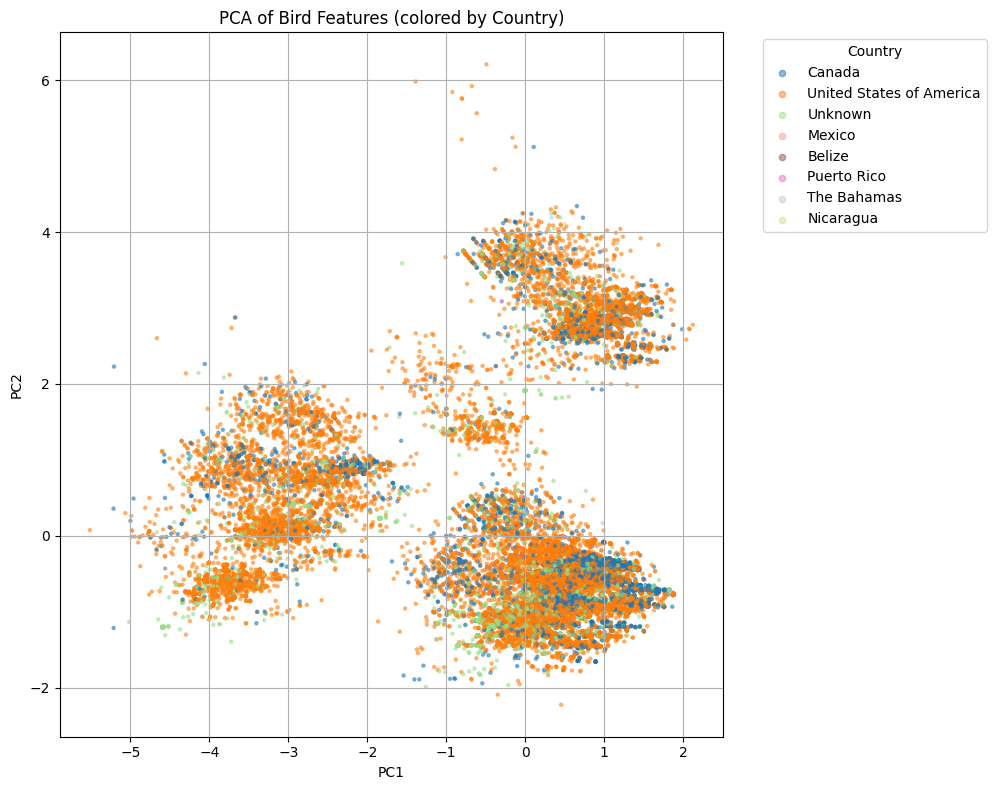

In [19]:
# --- PCA Visualization of Bird Features ---
pca_features = ['banding_month', 'season', 'banding_age_code', 'banding_extra_info_code', 'banding_species_id', 'banding_band_type_code', 'last_present_condition', 'banding_sex_code', 'last_reporting_method', 'last_how_obtained_code', 'banding_record_source'] # Using a broader set of relevant features for PCA

X_pca_pl = df.select(pca_features)
if 'season' in X_pca_pl.columns:
    X_pca_pl = X_pca_pl.to_dummies(columns=['season'])
X_pca = X_pca_pl.to_pandas()

# Encode remaining categorical columns (except one-hot encoded 'season') using pandas and LabelEncoder
for col in X_pca.select_dtypes(include=['object', 'category']).columns:
    X_pca[col] = LabelEncoder().fit_transform(X_pca[col].astype(str))

# Fill missing values for numeric columns using pandas
for col in X_pca.select_dtypes(include=[np.number]).columns:
    # Fill missing values using the median of the column within X_pca itself
    X_pca[col] = X_pca[col].fillna(X_pca[col].median())

n_pca_samples = 50000 # OPTIONAL: adjust this

# Sample the data
if len(X_pca) > n_pca_samples:
    X_pca_sampled = X_pca.sample(n=n_pca_samples, random_state=42)
else:
    X_pca_sampled = X_pca


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_sampled.values)
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

# Prepare color labels (country) from the Polars DataFrame, sampling to match the PCA data
country_labels_pl = df.select('country_from_geom')
country_labels_pd = country_labels_pl.to_pandas().squeeze()

# Sample the country labels to match the sampled PCA data
if len(country_labels_pd) > n_pca_samples:
    country_labels_sampled = country_labels_pd.sample(n=n_pca_samples, random_state=42)
else:
    country_labels_sampled = country_labels_pd

# Use pandas factorize to get numerical labels and unique categories for the legend
color_labels, unique_countries = pd.factorize(country_labels_sampled.astype(str))


# Plot PCA
plt.figure(figsize=(12,8)) # Increased figure size for better readability
scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=color_labels, cmap='tab20', alpha=0.5, s=5) # Increased marker size

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Bird Features (colored by Country)')

# Create a legend
legend_elements = [plt.scatter([], [], marker='o', color=plt.cm.tab20(i/len(unique_countries)), label=country, alpha=0.5, s=20) for i, country in enumerate(unique_countries)]
plt.legend(handles=legend_elements, title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.show()